# 2. Sparse Attention (Dikkat)

'Yapay zeka modelleri uzun metinleri işlerken zorlanır' cümlesi için Full vs. Sparse Attention Analizi
Sparse Attention Pencere Boyutu: 1 (her kelime sağına ve soluna 1 kelimeye bakar)
1-4. Adımlar: Gömme, Q,K,V, Skor ve Ölçekleme işlemleri her iki yöntem için de ortaktır.
Ölçeklenmiş Skor Matrisi:
[[19.   12.66 18.05 14.02 19.24 16.08 15.45]
 [12.83  8.65 12.31  9.56 13.27 10.98 10.42]
 [16.39 11.06 15.57 12.08 16.62 13.87 13.39]
 [15.85 10.61 15.09 11.73 16.12 13.46 12.88]
 [18.89 12.63 17.97 13.92 19.22 15.98 15.39]
 [18.56 12.44 17.67 13.72 18.88 15.74 15.11]
 [15.62 10.41 14.86 11.54 15.86 13.24 12.69]]
--------------------------------------------------------------------------------
a) Full Attention Ağırlıkları (Softmax uygulanmış hali)
[[0.36 0.   0.14 0.   0.46 0.02 0.01]
 [0.29 0.   0.17 0.01 0.45 0.05 0.03]
 [0.35 0.   0.15 0.   0.44 0.03 0.02]
 [0.34 0.   0.16 0.01 0.45 0.03 0.02]
 [0.35 0.   0.14 0.   0.48 0.02 0.01]
 [0.35 0.   0.14 0.   0.48 0.02 0.01]
 [0.34 0.   0.16 0.

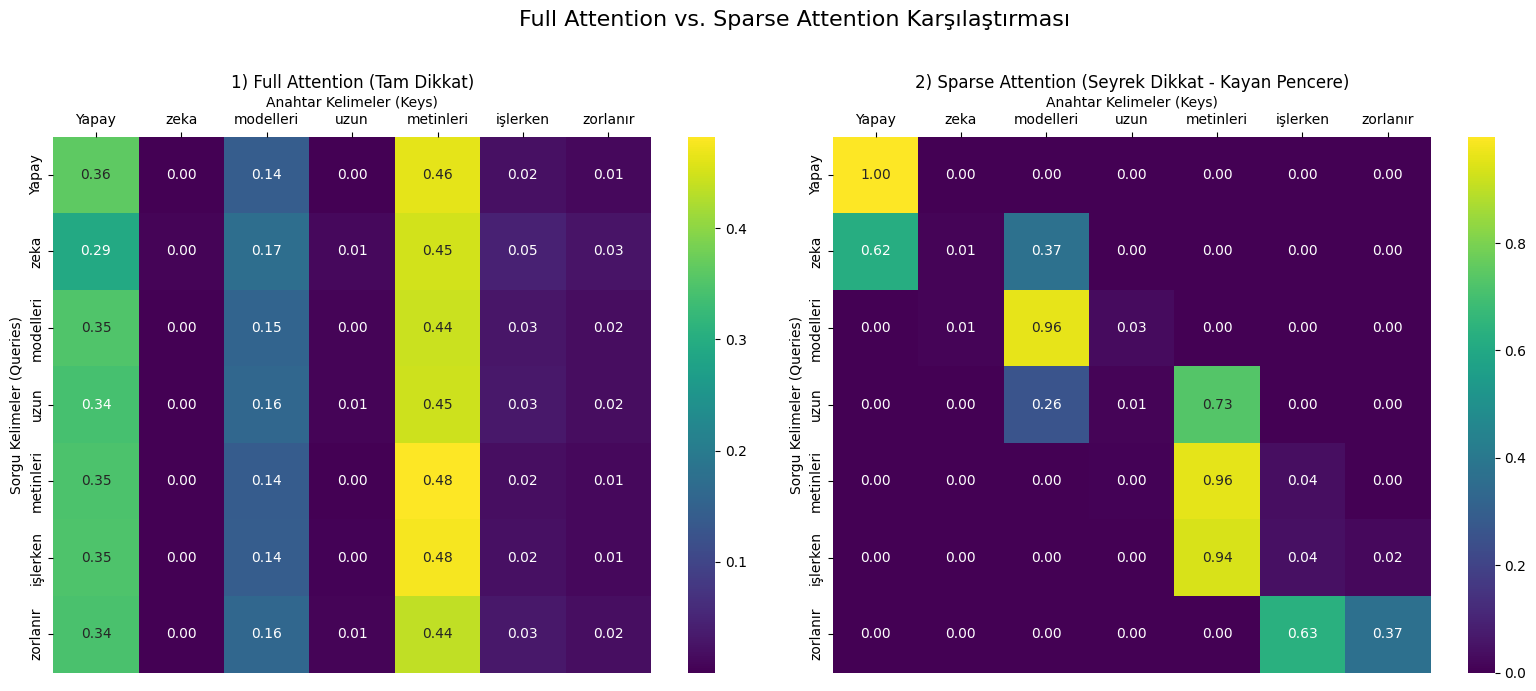

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- Bir önceki koddan alınan yardımcı fonksiyonlar ---
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

# YENİ KARŞILAŞTIRMA GÖRSELLEŞTİRME FONKSİYONU
def visualize_attention_comparison(sentence, full_attention_matrix, sparse_attention_matrix):
    """Full ve Sparse Attention matrislerini yan yana görselleştirir."""
    
    # Türkçe karakter desteği için font ayarı
    try:
        font_prop = fm.FontProperties(fname='/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', size=10)
        plt.rcParams['font.family'] = font_prop.get_name()
    except:
        print("\nUyarı: 'DejaVu Sans' fontu bulunamadı. Görseldeki etiketler düzgün görünmeyebilir.\n")
    
    tokens = sentence.split()
    
    # İki grafiği yan yana çizmek için bir figure ve subplotlar oluştur
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Sol Grafik: Full Attention
    sns.heatmap(full_attention_matrix, xticklabels=tokens, yticklabels=tokens, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
    axes[0].set_title("1) Full Attention (Tam Dikkat)")
    axes[0].set_xlabel("Anahtar Kelimeler (Keys)")
    axes[0].set_ylabel("Sorgu Kelimeler (Queries)")
    axes[0].xaxis.tick_top()
    axes[0].xaxis.set_label_position('top')
    
    # Sağ Grafik: Sparse Attention
    sns.heatmap(sparse_attention_matrix, xticklabels=tokens, yticklabels=tokens, annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
    axes[1].set_title("2) Sparse Attention (Seyrek Dikkat - Kayan Pencere)")
    axes[1].set_xlabel("Anahtar Kelimeler (Keys)")
    axes[1].set_ylabel("Sorgu Kelimeler (Queries)")
    axes[1].xaxis.tick_top()
    axes[1].xaxis.set_label_position('top')
    
    fig.suptitle("Full Attention vs. Sparse Attention Karşılaştırması", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# YENİ MASKE OLUŞTURMA FONKSİYONU
def create_sliding_window_mask(sequence_length, window_size):
    """
    Kayan pencere (sliding window) sparse attention için bir maske oluşturur.
    Pencere dışındaki pozisyonlara -infinity değeri atanır.
    """
    mask = np.zeros((sequence_length, sequence_length))
    for i in range(sequence_length):
        for j in range(sequence_length):
            # Eğer j pozisyonu, i'nin penceresi dışındaysa, maskele
            if abs(i - j) > window_size:
                mask[i, j] = -np.inf
    return mask

def attention_comparison_step_by_step(sentence, window_size=1):
    """
    Full ve Sparse Attention mekanizmalarını karşılaştırır.
    """
    print(f"'{sentence}' cümlesi için Full vs. Sparse Attention Analizi")
    print(f"Sparse Attention Pencere Boyutu: {window_size} (her kelime sağına ve soluna {window_size} kelimeye bakar)")
    print("=" * 80)

    tokens = sentence.split()
    vocab_size = len(tokens)
    
    # --- 1. ve 2. Adımlar (Ortak) ---
    d_model = 12
    d_k = 4
    np.random.seed(42) 
    
    embeddings = np.random.rand(vocab_size, d_model)
    W_q = np.random.rand(d_model, d_k)
    W_k = np.random.rand(d_model, d_k)
    W_v = np.random.rand(d_model, d_k)
    
    Q = embeddings @ W_q
    K = embeddings @ W_k
    V = embeddings @ W_v
    
    # --- 3. ve 4. Adımlar (Ortak) ---
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    
    print("1-4. Adımlar: Gömme, Q,K,V, Skor ve Ölçekleme işlemleri her iki yöntem için de ortaktır.")
    print("Ölçeklenmiş Skor Matrisi:")
    print(np.round(scaled_scores, 2))
    print("-" * 80)
    
    # --- FULL ATTENTION HESAPLAMASI ---
    full_attention_weights = softmax(scaled_scores)
    print("a) Full Attention Ağırlıkları (Softmax uygulanmış hali)")
    print(np.round(full_attention_weights, 2))
    print("-" * 80)

    # --- SPARSE ATTENTION HESAPLAMASI ---
    
    # 5. Adım: Seyreltme Maskesi Oluşturma (YENİ ADIM)
    print("b) Sparse Attention için adımlar:")
    print("5. Adım: Kayan Pencere Maskesi Oluşturma")
    print("Pencere dışındaki konumlara -inf değeri atanır, böylece softmax sonrası skorları 0 olur.")
    mask = create_sliding_window_mask(vocab_size, window_size)
    print(mask)
    print("-" * 80)
    
    # 6. Adım: Maskeyi Uygulama (YENİ ADIM)
    print("6. Adım: Maskenin Ölçeklenmiş Skorlara Uygulanması")
    masked_scores = scaled_scores + mask
    print("Maske uygulandıktan sonraki skorlar (softmax öncesi):")
    print(np.round(masked_scores, 2))
    print("-" * 80)
    
    # 7. Adım: Maskeli Skorlara Softmax Uygulama
    sparse_attention_weights = softmax(masked_scores)
    print("7. Adım: Sparse Attention Ağırlıkları (Maskeli skorlara Softmax uygulanmış hali)")
    print("Dikkat'in sadece komşu kelimelere odaklandığına dikkat edin.")
    print(np.round(sparse_attention_weights, 2))
    print("-" * 80)
    
    # --- 8. Adım: Karşılaştırmalı Görselleştirme ---
    print("8. Adım: Sonuçların Karşılaştırılması")
    print("İki dikkat matrisi şimdi görselleştirilecek...")
    visualize_attention_comparison(sentence, full_attention_weights, sparse_attention_weights)

if __name__ == '__main__':
    # Sparse attention etkisini daha iyi görmek için biraz daha uzun bir cümle
    ornek_cumle = "Yapay zeka modelleri uzun metinleri işlerken zorlanır"
    
    # Pencere boyutu: Her kelime, sağındaki ve solundaki 1 kelimeye dikkat eder.
    # Bu değeri 2 veya 3 yaparak pencereyi genişletebilirsiniz.
    pencere_boyutu = 1
    
    attention_comparison_step_by_step(ornek_cumle, window_size=pencere_boyutu)